# 串扰仿真 v10 —— 长焦 A 组 16 激光器编码鬼影检测（理想 δ 回波）

> **目标**：忠实记录"谁发光 → 碰到多远的物体 → 被谁在自己的 TOF 窗里收到 → 算成了多远"，
> 用几个特定距离验证仿真逻辑是否正确。暂不做全距离扫描、不做波形/蒙卡（那是 v44 的事）。

## 一、物理模型（理想化）
- 回波是 **δ 函数**，被 **100% 确定性** 记录到准确时刻。
- 物体回波 **被每一个激光器接收**：只要回波时刻落在某激光器的 TOF 窗内，就被它记录。
- 因此天然涌现三类鬼影：
  1. **同 kick 串扰**：同一 kick 内多个激光器几乎同时发光，回波互相落进对方的窗；
  2. **距离混叠（TOF 外鬼影）**：D>300m 的回波超过 2μs 窗，落入后续 kick 的窗；
  3. **编码残差**：接收器按【自己】的编码扣延迟测距，残留 (发射编码−接收编码) 决定鬼影落点。

## 二、时间 / 距离公式
```
t_fire = kick×KICK_SPACING + tx_trig_dly·1ns + delta_dly·(1/12)ns + fpga·8ns
t_ref  = t_fire − delta_dly·(1/12)ns          # "激光器(除去 delta_dly 的延时)"
t_echo = t_fire_发 + 2D/c
记录条件： t_fire_收 ≤ t_echo ≤ t_fire_收 + TOF_WINDOW
rec_tof = t_echo − t_ref_收        rec_dist = rec_tof · c / 2
is_true = (发激光==收激光) 且 (同一 kick)     # 其余均为鬼影
```

## 三、本版参数
- 数据源：`Elephant 时序表.xlsx` 的 **长焦** tab、**A 组**（16 激光器，每个发 4 次光）。
- `KICK_SPACING = 2.2 μs`，`TOF_WINDOW = 2000 ns`（固定），`1ns bin = 15cm`，`2000ns = 300m`。
- 编码：`tx_trig_dly` 用 Excel(0/50ns)；`delta_dly=0`（留接口）；`fpga_jitter=0`（留接口）。


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import openpyxl

# 中文字体
for _f in ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "Source Han Sans SC"]:
    try:
        matplotlib.rcParams["font.sans-serif"] = [_f]; break
    except Exception:
        continue
matplotlib.rcParams["axes.unicode_minus"] = False

# ---- 物理常数 ----
C_LIGHT = 2.99792458e8      # 光速 [m/s]
NS = 1e-9                   # 1 ns [s]

# ---- 系统时序常数（用户设定，勿擅改）----
KICK_SPACING = 2.2e-6       # 相邻 kick 基线间隔 [s]（2.2 μs）
TOF_WINDOW   = 2000e-9      # 固定 TOF 窗宽 [s]（2000 ns）
D_UNAMBIG    = TOF_WINDOW * C_LIGHT / 2.0   # 最大无模糊距离 [m]（=300m）

print("模块导入完成。")
print(f"  光速          = {C_LIGHT:.6e} m/s")
print(f"  1 ns 往返距离 = {C_LIGHT*NS/2*100:.2f} cm")
print(f"  KICK_SPACING  = {KICK_SPACING*1e6:.2f} μs")
print(f"  TOF_WINDOW    = {TOF_WINDOW*1e9:.0f} ns  ->  最大无模糊距离 D_UNAMBIG = {D_UNAMBIG:.1f} m")
print(f"  kick 窗间隙   = {(KICK_SPACING-TOF_WINDOW)*1e9:.0f} ns  ->  对应距离 {(KICK_SPACING-TOF_WINDOW)*C_LIGHT/2:.1f} m")


模块导入完成。
  光速          = 2.997925e+08 m/s
  1 ns 往返距离 = 14.99 cm
  KICK_SPACING  = 2.20 μs
  TOF_WINDOW    = 2000 ns  ->  最大无模糊距离 D_UNAMBIG = 299.8 m
  kick 窗间隙   = 200 ns  ->  对应距离 30.0 m


In [2]:
# ============================================================================
# 读取时序：长焦 tab、A 组（列 8~23 = kick 0~15）
# ============================================================================
# 表结构（长焦 tab）：
#   R3 = 各 kick 的 TOF(us)   R4 = tdelay(=delta_dly, 1/12ns 步长)   R6 = kick 编号
#   数据行：C2=HDC C3=TX_TRG C5=CHG C6=LASER，列 8~23 = 各 kick 的 tx_trig_dly（空=该 kick 不发光）
EXCEL_FILE = "Elephant 时序表.xlsx"
wb = openpyxl.load_workbook(EXCEL_FILE, data_only=True)
ws = wb["长焦"]                       # 第一个 tab = 长焦
COL_A = range(8, 24)                   # A 组 16 个 kick 所在列

# ---- A 组每个 kick 的 delta_dly（Excel 第 4 行 tdelay，单位 1/12 ns）----
#   本版 use_delta_dly=False 时不参与计算，但先解析保留，方便以后打开。
tdelay_A = {}
for c in COL_A:
    v = ws.cell(4, c).value
    tdelay_A[c - 8] = int(v) if v is not None else 0

# ---- A 组每个 kick 的 TOF(us)（Excel 第 3 行；本版统一用固定 TOF_WINDOW，这里仅供参考）----
tof_excel_A = {}
for c in COL_A:
    v = ws.cell(3, c).value
    tof_excel_A[c - 8] = float(v) if v is not None else None

# ---- 解析所有激光器发光行 ----
#   每个发光单元： (laser_id, kick_idx, tx_trig_dly)
laser_fires_raw = []      # 原始发光记录（未算时间）
laser_ids = []
for r in range(7, 106):
    las = ws.cell(r, 6).value
    if las is None:
        continue
    try:
        lid = int(las)
    except (ValueError, TypeError):
        continue
    laser_ids.append(lid)
    for k, c in enumerate(COL_A):
        v = ws.cell(r, c).value
        if v is not None:
            laser_fires_raw.append((lid, k, int(v)))    # (激光器, kick, tx_trig_dly)

laser_ids = sorted(set(laser_ids))
N_LASERS = len(laser_ids)

print(f"从 {EXCEL_FILE} [长焦/A组] 读取：{N_LASERS} 个激光器，{len(laser_fires_raw)} 次发光事件")
print(f"\nA 组各 kick 参数：")
print(f"  kick   : " + " ".join(f"{k:>3d}" for k in range(16)))
print(f"  delta  : " + " ".join(f"{tdelay_A[k]:>3d}" for k in range(16)) + "   (1/12 ns, 本版=0)")
print(f"  tof(us): " + " ".join(f"{str(tof_excel_A[k]):>3s}" for k in range(16)) + "   (Excel原值, 本版统一2μs)")

print(f"\n各激光器发光次数：")
for lid in laser_ids:
    fires = [(k, tx) for (l, k, tx) in laser_fires_raw if l == lid]
    ks = ",".join(f"K{k}(tx={tx})" for k, tx in fires)
    print(f"  L{lid:>2d}: {len(fires)}次 -> {ks}")


从 Elephant 时序表.xlsx [长焦/A组] 读取：16 个激光器，64 次发光事件

A 组各 kick 参数：
  kick   :   0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15
  delta  :   0   3   6   0   3   6   9   0   3   6   9   0   3   6   9   9   (1/12 ns, 本版=0)
  tof(us): 2.0 2.0 2.0 2.0 2.0 2.0 2.0 1.0 1.0 1.0 2.0 1.0 1.0 1.0 1.0 1.0   (Excel原值, 本版统一2μs)

各激光器发光次数：
  L 1: 4次 -> K7(tx=0),K8(tx=0),K9(tx=0),K15(tx=0)
  L 2: 4次 -> K11(tx=0),K12(tx=0),K13(tx=0),K14(tx=0)
  L 3: 4次 -> K7(tx=50),K8(tx=50),K9(tx=50),K15(tx=50)
  L 4: 4次 -> K11(tx=50),K12(tx=50),K13(tx=50),K14(tx=50)
  L 5: 4次 -> K0(tx=0),K1(tx=0),K2(tx=0),K6(tx=0)
  L 6: 4次 -> K3(tx=0),K4(tx=0),K5(tx=0),K10(tx=0)
  L 7: 4次 -> K0(tx=50),K1(tx=50),K2(tx=50),K6(tx=50)
  L 8: 4次 -> K3(tx=50),K4(tx=50),K5(tx=50),K10(tx=50)
  L 9: 4次 -> K0(tx=0),K1(tx=0),K2(tx=0),K6(tx=0)
  L10: 4次 -> K3(tx=0),K4(tx=0),K5(tx=0),K10(tx=0)
  L11: 4次 -> K0(tx=50),K1(tx=50),K2(tx=50),K6(tx=50)
  L12: 4次 -> K3(tx=50),K4(tx=50),K5(tx=50),K10(tx=50)
  L13: 4次 -> K7(tx=0),K8(tx=0),K9(tx

In [3]:
# ============================================================================
# 编码配置（三参数开关 + 数值接口）与发光时刻计算
# ============================================================================
# 三个编码块（需求第 4 行）：
#   1) tx_trig_dly : 1 ns 步长 —— 本版按 Excel 用 0 / 50 ns
#   2) delta_dly   : 1/12 ns 步长 —— 本版全设 0（探高反目标才用；接口保留）
#   3) fpga_jitter : 8 ns 步长的 FPGA 随机抖动 —— 本版全设 0（重要编码方式；接口保留）
ENC = {
    "use_tx_trig_dly": True,    # True: 用 Excel 的 0/50ns；False: 全当 0
    "use_delta_dly":   False,   # 本版 False（全 0）。改 True 则启用 Excel 第4行 tdelay
    "use_fpga_jitter": False,   # 本版 False（全 0）。改 True 则启用 FPGA_JITTER_STEPS
}

# FPGA 抖动接口：每激光器的抖动步数（×8ns）。本版全 0。
#   注：真实 FPGA 抖动可能逐 shot 随机；此处先做"每激光器一个固定步数"的占位接口。
FPGA_JITTER_STEPS = {lid: 0 for lid in laser_ids}


def delta_offset(kick_idx):
    """该 kick 的 delta_dly 贡献 [s]（1/12 ns 步长）。use_delta_dly=False 时恒为 0。"""
    if not ENC["use_delta_dly"]:
        return 0.0
    return tdelay_A.get(kick_idx, 0) * (NS / 12.0)


def fpga_offset(laser_id):
    """该激光器的 FPGA 抖动贡献 [s]（8 ns 步长）。use_fpga_jitter=False 时恒为 0。"""
    if not ENC["use_fpga_jitter"]:
        return 0.0
    return FPGA_JITTER_STEPS.get(laser_id, 0) * 8.0 * NS


def fire_time(laser_id, kick_idx, tx_trig_dly):
    """激光器实际发光时刻 [s]（绝对时间轴）。
       = kick 基线 + tx_trig_dly·1ns + delta_dly·(1/12)ns + fpga·8ns"""
    base = kick_idx * KICK_SPACING
    t_tx = (tx_trig_dly * NS) if ENC["use_tx_trig_dly"] else 0.0
    return base + t_tx + delta_offset(kick_idx) + fpga_offset(laser_id)


def ref_time(laser_id, kick_idx, tx_trig_dly):
    """测距参考零点 [s] = t_fire − delta_dly 部分（"激光器除去 delta_dly 的延时"）。
       接收器用它把回波时刻换算成 rec_tof。delta=0 时 ref==fire。"""
    return fire_time(laser_id, kick_idx, tx_trig_dly) - delta_offset(kick_idx)


# ---- 构建【发光事件表】：每一行既是一次发射，也开启一个 2μs 接收窗 ----
#   字段：laser, kick, tx, t_fire(实际发光), t_ref(测距参考零点)
firings = []
for (lid, k, tx) in laser_fires_raw:
    firings.append({
        "laser":  lid,
        "kick":   k,
        "tx":     tx,
        "t_fire": fire_time(lid, k, tx),
        "t_ref":  ref_time(lid, k, tx),
    })
firings.sort(key=lambda e: e["t_fire"])
N_FIRE = len(firings)

print(f"编码开关：{ENC}")
print(f"发光事件表：共 {N_FIRE} 行（每行 = 一次发射 + 一个 {TOF_WINDOW*1e9:.0f}ns 接收窗）\n")
print(f"  {'#':>3} {'Laser':>5} {'Kick':>4} {'tx[ns]':>6} {'t_fire[ns]':>13} {'窗口[ns]':>22}")
print(f"  {'-'*3} {'-'*5} {'-'*4} {'-'*6} {'-'*13} {'-'*22}")
for i, e in enumerate(firings):
    win = f"[{e['t_fire']*1e9:.0f}, {(e['t_fire']+TOF_WINDOW)*1e9:.0f}]"
    print(f"  {i:>3d} {e['laser']:>5d} {e['kick']:>4d} {e['tx']:>6d} {e['t_fire']*1e9:>13.2f} {win:>22}")


编码开关：{'use_tx_trig_dly': True, 'use_delta_dly': False, 'use_fpga_jitter': False}
发光事件表：共 64 行（每行 = 一次发射 + 一个 2000ns 接收窗）

    # Laser Kick tx[ns]    t_fire[ns]                 窗口[ns]
  --- ----- ---- ------ ------------- ----------------------
    0     5    0      0          0.00              [0, 2000]
    1     9    0      0          0.00              [0, 2000]
    2     7    0     50         50.00             [50, 2050]
    3    11    0     50         50.00             [50, 2050]
    4     5    1      0       2200.00           [2200, 4200]
    5     9    1      0       2200.00           [2200, 4200]
    6     7    1     50       2250.00           [2250, 4250]
    7    11    1     50       2250.00           [2250, 4250]
    8     5    2      0       4400.00           [4400, 6400]
    9     9    2      0       4400.00           [4400, 6400]
   10     7    2     50       4450.00           [4450, 6450]
   11    11    2     50       4450.00           [4450, 6450]
   12     6    3      0 

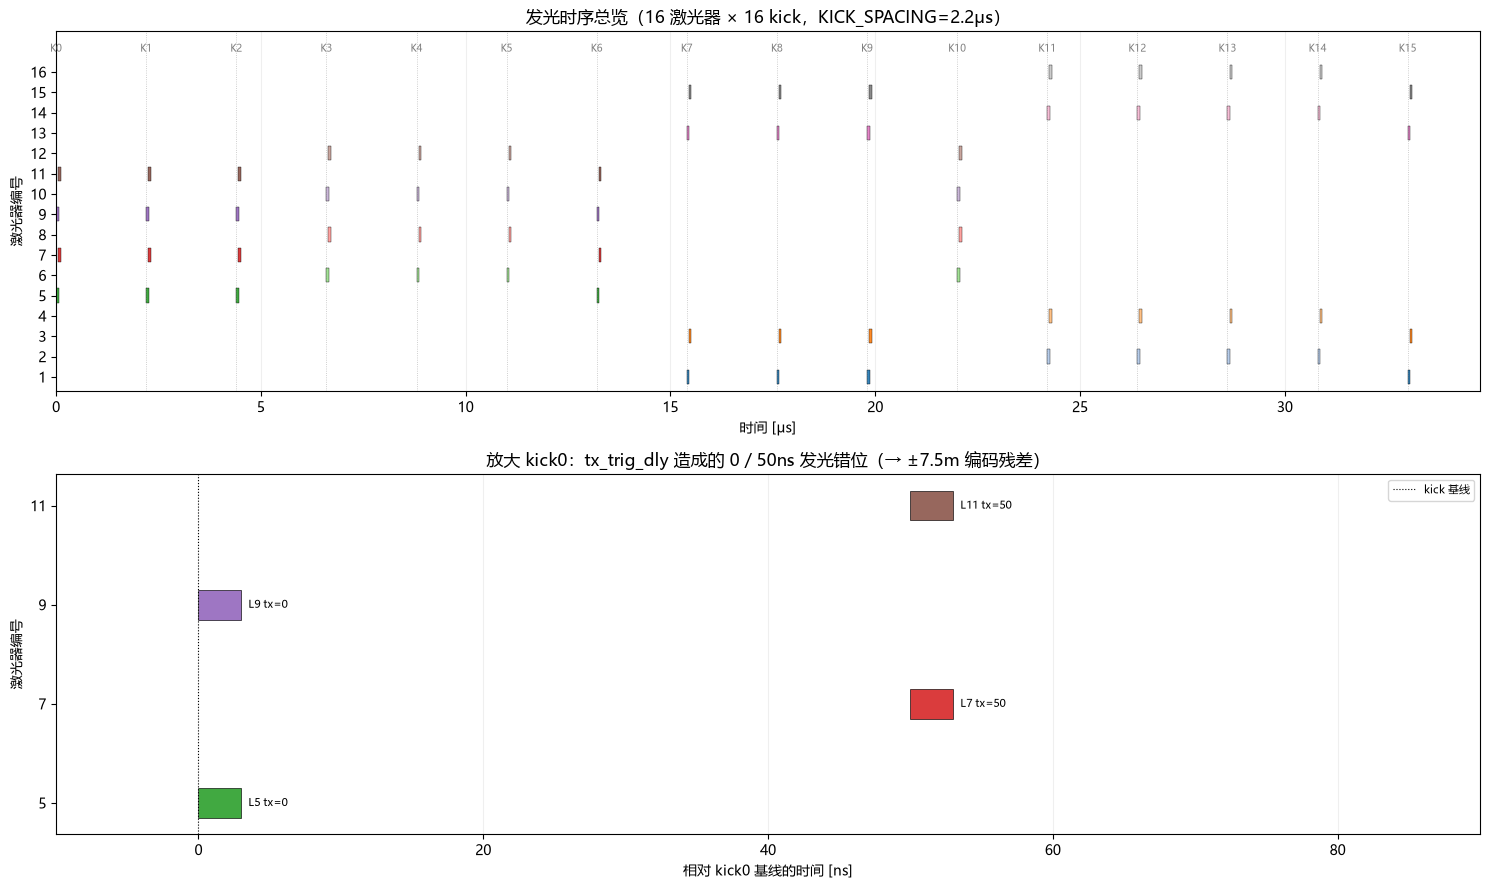

已保存 crosstalk_v10_timing.png


In [4]:
# ============================================================================
# 绘图 1：激光发光时序图（16 激光器 × 16 kick）
# ============================================================================
fig, axes = plt.subplots(2, 1, figsize=(15, 9))

# --- 上图：全 16 kick 总览（横轴 μs）---
ax = axes[0]
cmap = plt.cm.tab20
for e in firings:
    ax.barh(e["laser"], width=0.06, left=e["t_fire"]*1e6, height=0.7,
            color=cmap((e["laser"]-1) % 20), edgecolor="k", linewidth=0.3, alpha=0.9)
for k in range(16):
    base_us = k * KICK_SPACING * 1e6
    ax.axvline(base_us, color="gray", ls=":", lw=0.6, alpha=0.5)
    ax.text(base_us, N_LASERS + 1.0, f"K{k}", fontsize=7, ha="center", color="gray")
ax.set_xlabel("时间 [μs]"); ax.set_ylabel("激光器编号")
ax.set_yticks(laser_ids); ax.set_ylim(0.3, N_LASERS + 2)
ax.set_title(f"发光时序总览（{N_LASERS} 激光器 × 16 kick，KICK_SPACING={KICK_SPACING*1e6:.1f}μs）")
ax.grid(alpha=0.2, axis="x")

# --- 下图：放大 kick 0（看 tx_trig_dly 的 0 / 50ns 错位）---
ax = axes[1]
k_zoom = 0
base = k_zoom * KICK_SPACING
zoom_fires = [e for e in firings if e["kick"] == k_zoom]
for e in zoom_fires:
    off_ns = (e["t_fire"] - base) * 1e9
    ax.barh(e["laser"], width=3, left=off_ns, height=0.6,
            color=cmap((e["laser"]-1) % 20), edgecolor="k", linewidth=0.5, alpha=0.9)
    ax.text(off_ns + 3.5, e["laser"], f"L{e['laser']} tx={e['tx']}",
            fontsize=8, va="center")
ax.axvline(0, color="k", ls=":", lw=0.8, label="kick 基线")
ax.set_xlabel(f"相对 kick{k_zoom} 基线的时间 [ns]"); ax.set_ylabel("激光器编号")
ax.set_yticks([e["laser"] for e in zoom_fires])
ax.set_xlim(-10, 90)
ax.set_title(f"放大 kick{k_zoom}：tx_trig_dly 造成的 0 / 50ns 发光错位（→ ±7.5m 编码残差）")
ax.legend(fontsize=8); ax.grid(alpha=0.2, axis="x")

plt.tight_layout()
plt.savefig("crosstalk_v10_timing.png", dpi=110, bbox_inches="tight")
plt.show()
print("已保存 crosstalk_v10_timing.png")


In [5]:
# ============================================================================
# 核心检测：对给定物体距离 D，记录所有回波被各激光器接收的情况
# ============================================================================
def detect_echoes(D):
    """对距离 D 处的单个物体，返回所有"被记录的回波"列表。

    每条记录（dict）字段：
      emit_laser / emit_kick : 回波由哪个激光器、哪次 kick 发出
      recv_laser / recv_kick : 被哪个激光器、在它哪次 kick 的 TOF 窗里收到
      target_D               : 物体真实距离 [m]
      true_tof               : 真实飞行时间 2D/c [s]
      t_echo                 : 回波到达绝对时刻 [s]
      rec_tof                : 记录的飞行时间 = t_echo − t_ref_收 [s]
      rec_dist               : 记录的距离 = rec_tof·c/2 [m]（鬼影会 ≠ D）
      is_true                : 是否真回波（发==收 且 同一 kick）
    """
    t_tof = 2.0 * D / C_LIGHT
    recs = []
    for e in firings:                       # 每个发射事件
        t_echo = e["t_fire"] + t_tof
        for w in firings:                   # 检查每个接收窗（含自己）
            if w["t_fire"] <= t_echo <= w["t_fire"] + TOF_WINDOW:
                rec_tof = t_echo - w["t_ref"]
                recs.append({
                    "emit_laser": e["laser"], "emit_kick": e["kick"],
                    "recv_laser": w["laser"], "recv_kick": w["kick"],
                    "target_D": D, "true_tof": t_tof, "t_echo": t_echo,
                    "rec_tof": rec_tof, "rec_dist": rec_tof * C_LIGHT / 2.0,
                    "is_true": (e["laser"] == w["laser"] and e["kick"] == w["kick"]),
                })
    return recs


# ---- 快速自检：一个近距离物体 ----
_D = 30.0
_r = detect_echoes(_D)
_nt = sum(1 for x in _r if x["is_true"])
print(f"自检 D={_D:.0f}m：共 {len(_r)} 条记录，其中真回波 {_nt} 条、鬼影 {len(_r)-_nt} 条")
print(f"  真实 tof = {2*_D/C_LIGHT*1e9:.2f} ns（真实距离 {_D:.1f} m）")
if _r:
    _g = [x for x in _r if not x["is_true"]]
    _gd = sorted(set(round(x["rec_dist"], 2) for x in _g))
    print(f"  鬼影出现的记录距离（去重）：{_gd} m")


自检 D=30m：共 256 条记录，其中真回波 64 条、鬼影 192 条
  真实 tof = 200.14 ns（真实距离 30.0 m）
  鬼影出现的记录距离（去重）：[22.51, 30.0, 37.49] m


In [6]:
# ============================================================================
# 验证：几个特定距离的鬼影分布（仿真 vs 解析预测）
# ============================================================================
# 选点用意：
#   D=30m  (2D/c=200ns)  —— 远小于窗，只有同 kick 串扰；tx=0/50ns → 预期 ±7.5m 鬼影
#   D=150m (2D/c=1000ns) —— 窗内正常测距；同 kick 串扰
#   D=330m (2D/c=2200ns) —— 恰好 = 1 个 KICK_SPACING！真回波超窗丢失，混叠进下一 kick
#   D=480m (2D/c=3202ns) —— 超窗，混叠进下一 kick 窗；预期伪装成 ~150m
D_TEST = [30.0, 150.0, 330.0, 480.0]

def dist_offset_from_tx(dtx_ns):
    """tx 差 dtx(ns) 对应的鬼影距离偏移 [m]。"""
    return dtx_ns * NS * C_LIGHT / 2.0

print("=" * 84)
print("特定距离验证（KICK_SPACING={:.1f}μs, TOF_WINDOW={:.0f}ns, D_UNAMBIG={:.0f}m）".format(
    KICK_SPACING*1e6, TOF_WINDOW*1e9, D_UNAMBIG))
print("=" * 84)

verify_cache = {}
for D in D_TEST:
    recs = detect_echoes(D)
    verify_cache[D] = recs
    n_true = sum(1 for x in recs if x["is_true"])
    n_ghost = len(recs) - n_true
    tof_ns = 2*D/C_LIGHT*1e9

    # 记录距离直方（按 0.1m 归并去重，看鬼影落在哪些"假距离"）
    from collections import Counter
    dist_cnt = Counter(round(x["rec_dist"], 1) for x in recs)
    ghost_cnt = Counter(round(x["rec_dist"], 1) for x in recs if not x["is_true"])

    print(f"\n【D = {D:.0f} m】 真实 tof = {tof_ns:.1f} ns  (2D/c)")
    print(f"  记录总数 {len(recs)}：真回波 {n_true}，鬼影 {n_ghost}")
    if 2*D/C_LIGHT > TOF_WINDOW:
        print(f"  ⚠ 2D/c={tof_ns:.0f}ns > 窗{TOF_WINDOW*1e9:.0f}ns  → 真回波超窗，本距离【无法被正确测距】(n_true应=0)")
    print(f"  各记录距离(≥1条) : " +
          ", ".join(f"{d}m×{c}" for d, c in sorted(dist_cnt.items())))

    # ---- 解析预测 ----
    if D <= D_UNAMBIG:
        # 同 kick 串扰：发/收 tx 差 ∈ {-50,0,+50} → 距离偏移 {-7.5,0,+7.5} m
        preds = sorted(set(round(D + dist_offset_from_tx(dtx), 1) for dtx in (-50, 0, 50)))
        print(f"  解析预测(同kick, tx差±50ns→±7.5m)：鬼影/真值应落在 {preds} m")
    else:
        # 混叠：回波落入下一个 kick 窗，rec_tof = 2D/c − KICK_SPACING (+ tx差)
        base_alias_ns = (2*D/C_LIGHT - KICK_SPACING) * 1e9
        base_alias_m = base_alias_ns * NS * C_LIGHT / 2.0
        preds = sorted(set(round(base_alias_m + dist_offset_from_tx(dtx), 1) for dtx in (-50, 0, 50)))
        print(f"  解析预测(混叠到下一kick: 2D/c−KICK_SPACING={base_alias_ns:.0f}ns)：鬼影应落在 {preds} m")

    # ---- 比对 ----
    sim_ghost = sorted(ghost_cnt.keys())
    ok = set(sim_ghost).issubset(set(preds)) or set(preds).issubset(set(sim_ghost + ([round(D,1)] if D<=D_UNAMBIG else [])))
    print(f"  仿真鬼影距离 = {sim_ghost} m   →  与解析预测 {'✔ 一致' if set(sim_ghost)<=set(preds) else '⚠ 需检查'}")


特定距离验证（KICK_SPACING=2.2μs, TOF_WINDOW=2000ns, D_UNAMBIG=300m）

【D = 30 m】 真实 tof = 200.1 ns  (2D/c)
  记录总数 256：真回波 64，鬼影 192
  各记录距离(≥1条) : 22.5m×64, 30.0m×128, 37.5m×64
  解析预测(同kick, tx差±50ns→±7.5m)：鬼影/真值应落在 [22.5, 30.0, 37.5] m
  仿真鬼影距离 = [22.5, 30.0, 37.5] m   →  与解析预测 ✔ 一致

【D = 150 m】 真实 tof = 1000.7 ns  (2D/c)
  记录总数 256：真回波 64，鬼影 192
  各记录距离(≥1条) : 142.5m×64, 150.0m×128, 157.5m×64
  解析预测(同kick, tx差±50ns→±7.5m)：鬼影/真值应落在 [142.5, 150.0, 157.5] m
  仿真鬼影距离 = [142.5, 150.0, 157.5] m   →  与解析预测 ✔ 一致

【D = 330 m】 真实 tof = 2201.5 ns  (2D/c)
  记录总数 180：真回波 0，鬼影 180
  ⚠ 2D/c=2202ns > 窗2000ns  → 真回波超窗，本距离【无法被正确测距】(n_true应=0)
  各记录距离(≥1条) : 0.2m×120, 7.7m×60
  解析预测(混叠到下一kick: 2D/c−KICK_SPACING=2ns)：鬼影应落在 [-7.3, 0.2, 7.7] m
  仿真鬼影距离 = [0.2, 7.7] m   →  与解析预测 ✔ 一致

【D = 480 m】 真实 tof = 3202.2 ns  (2D/c)
  记录总数 240：真回波 0，鬼影 240
  ⚠ 2D/c=3202ns > 窗2000ns  → 真回波超窗，本距离【无法被正确测距】(n_true应=0)
  各记录距离(≥1条) : 142.7m×60, 150.2m×120, 157.7m×60
  解析预测(混叠到下一kick: 2D/c−KICK_SPACING=1002ns)：鬼影应落在 [142.7, 150.

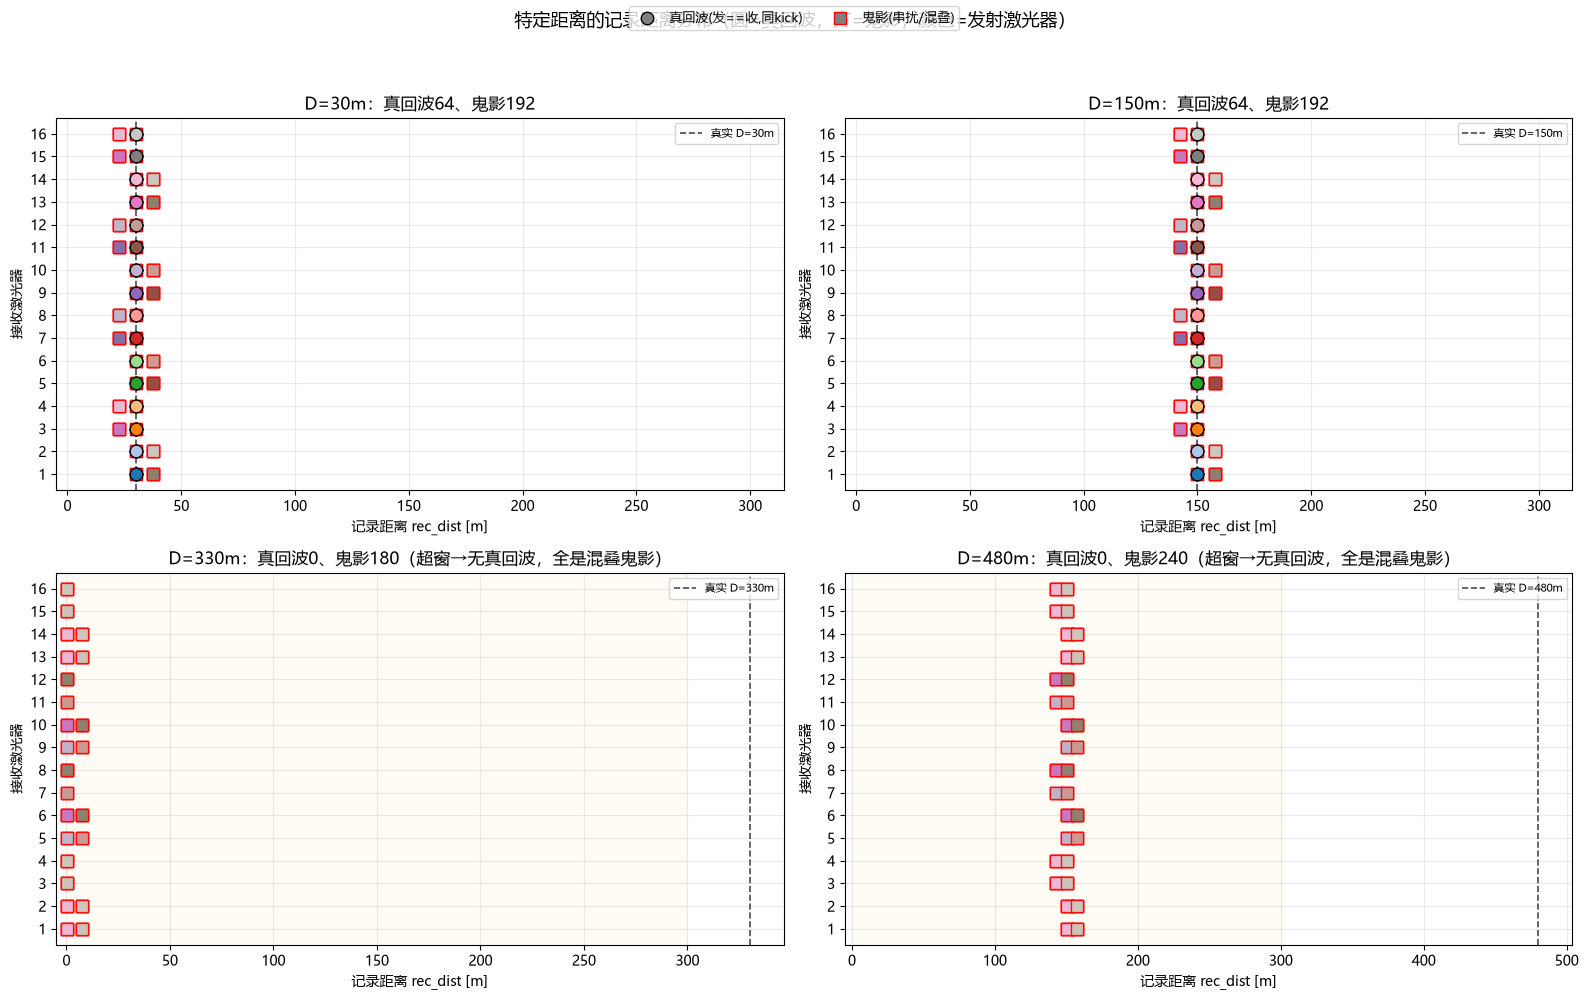

已保存 crosstalk_v10_echo_map.png


In [7]:
# ============================================================================
# 绘图 2：特定距离的"记录距离"分布图（横轴=算出的距离，纵轴=接收激光器）
# ============================================================================
# 圆=真回波（发==收，同kick），方=鬼影；颜色=发射激光器。
# 竖虚线=物体真实距离 D。看鬼影被"算成"了多远。
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
cmap = plt.cm.tab20

for ax, D in zip(axes.ravel(), D_TEST):
    recs = verify_cache[D]
    for x in recs:
        col = cmap((x["emit_laser"]-1) % 20)
        if x["is_true"]:
            ax.plot(x["rec_dist"], x["recv_laser"], "o", color=col, ms=9,
                    mec="k", mew=0.8, zorder=6)
        else:
            ax.plot(x["rec_dist"], x["recv_laser"], "s", color=col, ms=8,
                    mec="red", mew=0.9, zorder=5, alpha=0.85)
    ax.axvline(D, color="k", ls="--", lw=1.2, alpha=0.7, label=f"真实 D={D:.0f}m")
    if D > D_UNAMBIG:
        ax.axvspan(0, D_UNAMBIG*1.0, color="orange", alpha=0.04)
    n_true = sum(1 for x in recs if x["is_true"])
    ax.set_xlabel("记录距离 rec_dist [m]"); ax.set_ylabel("接收激光器")
    ax.set_yticks(laser_ids); ax.set_ylim(0.3, N_LASERS + 0.7)
    ax.set_xlim(-5, max(D_UNAMBIG, D) * 1.05)
    ax.set_title(f"D={D:.0f}m：真回波{n_true}、鬼影{len(recs)-n_true}"
                 + ("（超窗→无真回波，全是混叠鬼影）" if D > D_UNAMBIG else ""))
    ax.legend(fontsize=8, loc="upper right"); ax.grid(alpha=0.25)

# 图例说明
from matplotlib.lines import Line2D
legend_el = [
    Line2D([0], [0], marker="o", color="w", mfc="gray", mec="k", ms=9, label="真回波(发==收,同kick)"),
    Line2D([0], [0], marker="s", color="w", mfc="gray", mec="red", ms=8, label="鬼影(串扰/混叠)"),
]
fig.legend(handles=legend_el, loc="upper center", ncol=2, fontsize=9)
plt.suptitle("特定距离的记录距离分布（圆=真回波，方=鬼影，颜色=发射激光器）", y=0.995, fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("crosstalk_v10_echo_map.png", dpi=110, bbox_inches="tight")
plt.show()
print("已保存 crosstalk_v10_echo_map.png")


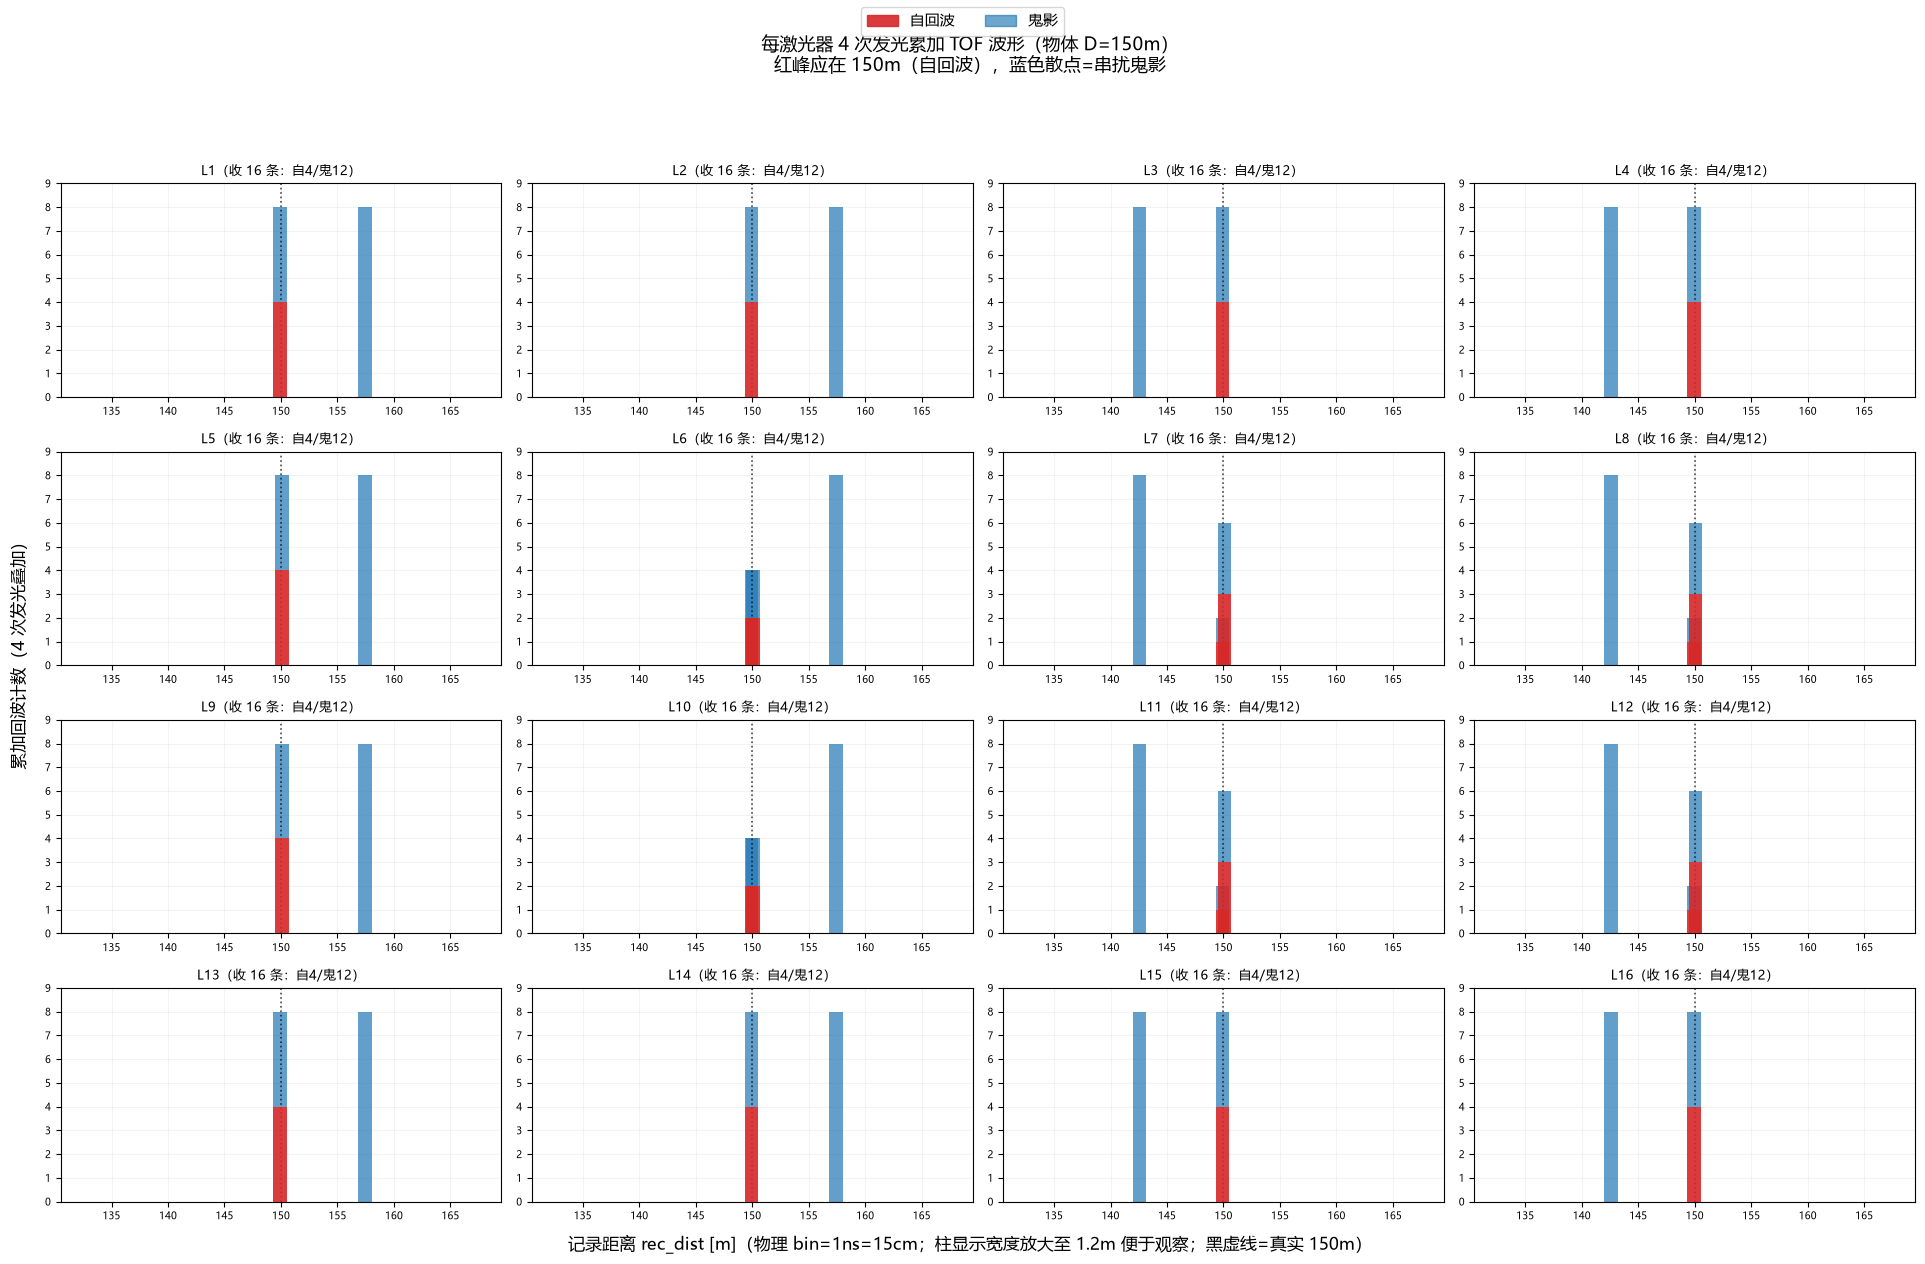

每激光器累加 TOF（D=150m）：
  Laser   收到   自回波   鬼影       自回波距离[m] 鬼影距离[m]
  L   1   16     4   12        [150.0] [150.0, 157.5]
  L   2   16     4   12        [150.0] [150.0, 157.5]
  L   3   16     4   12        [150.0] [142.5, 150.0]
  L   4   16     4   12        [150.0] [142.5, 150.0]
  L   5   16     4   12        [150.0] [150.0, 157.5]
  L   6   16     4   12        [150.0] [150.0, 157.5]
  L   7   16     4   12        [150.0] [142.5, 150.0]
  L   8   16     4   12        [150.0] [142.5, 150.0]
  L   9   16     4   12        [150.0] [150.0, 157.5]
  L  10   16     4   12        [150.0] [150.0, 157.5]
  L  11   16     4   12        [150.0] [142.5, 150.0]
  L  12   16     4   12        [150.0] [142.5, 150.0]
  L  13   16     4   12        [150.0] [150.0, 157.5]
  L  14   16     4   12        [150.0] [150.0, 157.5]
  L  15   16     4   12        [150.0] [142.5, 150.0]
  L  16   16     4   12        [150.0] [142.5, 150.0]


In [8]:
# ============================================================================
# 绘图 3：每个激光器的【4 次发光累加 TOF 波形】（需求第 19 行：把 4 次 tof 加起来）
# ============================================================================
# 对某个物体距离 D_CUMUL，每个激光器把自己 4 个 TOF 窗里收到的回波按"记录距离"累加成直方图。
# 红=自回波（该激光器自己发、自己收，同 kick）；蓝=鬼影（别的激光器/别的 kick 混进来）。
D_CUMUL = 150.0
recs_c = detect_echoes(D_CUMUL)

# 距离直方：1ns 时间 bin -> 0.15m 距离 bin（物理分辨率），范围 [0, 300m]
BIN_M = 0.15                                   # 物理 bin 宽 [m]（=1ns 往返）
bin_edges = np.arange(0, D_UNAMBIG + BIN_M, BIN_M)
bin_ctrs = 0.5 * (bin_edges[:-1] + bin_edges[1:])
# 柱子【显示】加宽：0.15m 的柱画在几十米窗里几乎不可见，放大显示宽度纯为看清，
#   不改物理分辨率（标题注明）。峰间距 7.5m，取 1.2m 显示宽既分得开又不糊在一起。
BW_SHOW = 1.2

# 全激光器回波落点范围 -> 统一 x 轴聚焦区间（比死画 0~300m 清楚得多）
_all_d = np.array([x["rec_dist"] for x in recs_c])
if _all_d.size:
    _xlo = max(0.0, _all_d.min() - 12); _xhi = min(D_UNAMBIG, _all_d.max() + 12)
else:
    _xlo, _xhi = 0.0, D_UNAMBIG

fig, axes = plt.subplots(4, 4, figsize=(20, 13))
for idx, lid in enumerate(laser_ids):
    ax = axes[idx // 4][idx % 4]
    mine = [x for x in recs_c if x["recv_laser"] == lid]
    d_self = np.array([x["rec_dist"] for x in mine if x["is_true"]])
    d_ghost = np.array([x["rec_dist"] for x in mine if not x["is_true"]])
    h_self, _ = np.histogram(d_self, bins=bin_edges)
    h_ghost, _ = np.histogram(d_ghost, bins=bin_edges)
    # 只画非零 bin（散点式柱），显示宽度 BW_SHOW
    m_s = h_self > 0
    ax.bar(bin_ctrs[m_s], h_self[m_s], width=BW_SHOW, color="tab:red",
           label="自回波", alpha=0.9, zorder=3)
    m_g = h_ghost > 0
    if m_g.any():
        ax.bar(bin_ctrs[m_g], h_ghost[m_g], width=BW_SHOW, bottom=h_self[m_g],
               color="tab:blue", label="鬼影", alpha=0.7, zorder=2)
    ax.axvline(D_CUMUL, color="k", ls=":", lw=1.2, alpha=0.7)
    ax.set_title(f"L{lid}（收 {len(mine)} 条：自{len(d_self)}/鬼{len(d_ghost)}）", fontsize=9)
    ax.set_xlim(_xlo, _xhi); ax.set_ylim(0, max(4, (h_self+h_ghost).max()+1))
    ax.tick_params(labelsize=7); ax.grid(alpha=0.15)

fig.text(0.5, 0.04, f"记录距离 rec_dist [m]（物理 bin=1ns=15cm；柱显示宽度放大至 {BW_SHOW}m 便于观察；黑虚线=真实 {D_CUMUL:.0f}m）",
         ha="center", fontsize=12)
fig.text(0.02, 0.5, "累加回波计数（4 次发光叠加）", va="center", rotation="vertical", fontsize=12)
handles = [plt.Rectangle((0,0),1,1,color="tab:red",alpha=0.9),
           plt.Rectangle((0,0),1,1,color="tab:blue",alpha=0.65)]
fig.legend(handles, ["自回波", "鬼影"], loc="upper center", ncol=2, fontsize=11)
plt.suptitle(f"每激光器 4 次发光累加 TOF 波形（物体 D={D_CUMUL:.0f}m）\n"
             f"红峰应在 {D_CUMUL:.0f}m（自回波），蓝色散点=串扰鬼影", fontsize=13, y=0.975)
plt.tight_layout(rect=[0.03, 0.05, 0.98, 0.93])
plt.savefig("crosstalk_v10_cumulative_tof.png", dpi=110, bbox_inches="tight")
plt.show()

print("=" * 76)
print(f"每激光器累加 TOF（D={D_CUMUL:.0f}m）：")
print(f"  {'Laser':>5} {'收到':>4} {'自回波':>5} {'鬼影':>4} {'自回波距离[m]':>14} {'鬼影距离[m]'}")
for lid in laser_ids:
    mine = [x for x in recs_c if x["recv_laser"] == lid]
    d_self = sorted(set(round(x["rec_dist"],1) for x in mine if x["is_true"]))
    d_ghost = sorted(set(round(x["rec_dist"],1) for x in mine if not x["is_true"]))
    print(f"  L{lid:>4d} {len(mine):>4d} "
          f"{sum(1 for x in mine if x['is_true']):>5d} "
          f"{sum(1 for x in mine if not x['is_true']):>4d} "
          f"{str(d_self):>14s} {d_ghost}")


In [9]:
# ============================================================================
# 总结
# ============================================================================
print("=" * 76)
print("crosstalk_sim_v10 总结")
print("=" * 76)
print(f"""
1. 数据源与配置
   - 时序：{EXCEL_FILE} [长焦 / A组]，{N_LASERS} 激光器 × 每个 4 次发光 = {N_FIRE} 发光事件
   - KICK_SPACING = {KICK_SPACING*1e6:.1f} μs，TOF_WINDOW = {TOF_WINDOW*1e9:.0f} ns
   - 最大无模糊距离 D_UNAMBIG = {D_UNAMBIG:.0f} m（超此距离真回波超窗 → 距离混叠鬼影）

2. 编码开关（本版）
   - tx_trig_dly : {'启用(Excel 0/50ns)' if ENC['use_tx_trig_dly'] else '关(全0)'}
   - delta_dly   : {'启用' if ENC['use_delta_dly'] else '关(全0，接口保留)'}
   - fpga_jitter : {'启用' if ENC['use_fpga_jitter'] else '关(全0，接口保留)'}

3. 核心模型
   - 每次发光 = 一次发射 + 一个 {TOF_WINDOW*1e9:.0f}ns 接收窗
   - 回波被每个激光器接收；落窗即记录 rec_tof = t_echo − t_ref_收
   - is_true = (发==收 且 同一 kick)；其余为鬼影

4. 验证结论（见上）
   - D≤300m：同 kick 串扰，tx=0/50ns 造成 ±7.5m 编码残差鬼影
   - D>300m：真回波超窗丢失，回波混叠进下一 kick 窗 → 伪装成近距离鬼影

5. 输出文件
   - crosstalk_v10_timing.png          发光时序图（总览 + kick0 放大）
   - crosstalk_v10_echo_map.png        4 个测试距离的记录距离分布
   - crosstalk_v10_cumulative_tof.png  每激光器 4 次发光累加 TOF 波形

6. 下一步（未做）
   - 打开 fpga_jitter（8ns 随机）看鬼影是否被打散
   - 全距离扫描 + 消鬼影算法（目标噪点率 10ppm）
   - 加入第二个模组 / 雷达对射
""")


crosstalk_sim_v10 总结

1. 数据源与配置
   - 时序：Elephant 时序表.xlsx [长焦 / A组]，16 激光器 × 每个 4 次发光 = 64 发光事件
   - KICK_SPACING = 2.2 μs，TOF_WINDOW = 2000 ns
   - 最大无模糊距离 D_UNAMBIG = 300 m（超此距离真回波超窗 → 距离混叠鬼影）

2. 编码开关（本版）
   - tx_trig_dly : 启用(Excel 0/50ns)
   - delta_dly   : 关(全0，接口保留)
   - fpga_jitter : 关(全0，接口保留)

3. 核心模型
   - 每次发光 = 一次发射 + 一个 2000ns 接收窗
   - 回波被每个激光器接收；落窗即记录 rec_tof = t_echo − t_ref_收
   - is_true = (发==收 且 同一 kick)；其余为鬼影

4. 验证结论（见上）
   - D≤300m：同 kick 串扰，tx=0/50ns 造成 ±7.5m 编码残差鬼影
   - D>300m：真回波超窗丢失，回波混叠进下一 kick 窗 → 伪装成近距离鬼影

5. 输出文件
   - crosstalk_v10_timing.png          发光时序图（总览 + kick0 放大）
   - crosstalk_v10_echo_map.png        4 个测试距离的记录距离分布
   - crosstalk_v10_cumulative_tof.png  每激光器 4 次发光累加 TOF 波形

6. 下一步（未做）
   - 打开 fpga_jitter（8ns 随机）看鬼影是否被打散
   - 全距离扫描 + 消鬼影算法（目标噪点率 10ppm）
   - 加入第二个模组 / 雷达对射

